In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

In [3]:
from google.colab import files
df = files.upload()

Saving train.csv to train.csv


In [4]:
df_test = files.upload()

Saving test.csv to test.csv


In [6]:
import io
df_train = pd.read_csv(io.BytesIO(df['train.csv']))
df_train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
df_test = pd.read_csv(io.BytesIO(df_test['test.csv']))
df_test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
df_train.isnull().sum().sum()

np.int64(0)

In [11]:
X_train = df_train.drop(columns = ['label'])
y_train = df_train['label'].values

In [12]:
df_test.columns

Index(['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=784)

In [13]:
X_test = df_test

In [14]:
X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

In [18]:
X_train = X_train.values
X_test = X_test.values

In [19]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [20]:
y_train_cat = to_categorical(y_train, 10)


In [24]:
from sklearn import metrics
perceptron = Sequential([
    Flatten(input_shape = (28, 28)),
    Dense(10, activation='softmax')
])
perceptron.compile(optimizer='sgd', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [25]:
hist_perceptron = perceptron.fit(X_train_img, y_train_cat, epochs = 10, batch_size = 32, validation_split=0.1, verbose = 1)

Epoch 1/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7837 - loss: 0.9150 - val_accuracy: 0.8607 - val_loss: 0.5730
Epoch 2/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8694 - loss: 0.5136 - val_accuracy: 0.8805 - val_loss: 0.4651
Epoch 3/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8826 - loss: 0.4427 - val_accuracy: 0.8883 - val_loss: 0.4202
Epoch 4/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8897 - loss: 0.4075 - val_accuracy: 0.8950 - val_loss: 0.3958
Epoch 5/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8949 - loss: 0.3857 - val_accuracy: 0.9000 - val_loss: 0.3791
Epoch 6/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8978 - loss: 0.3705 - val_accuracy: 0.9005 - val_loss: 0.3667
Epoch 7/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9007 - loss: 0.3589 - val_accuracy: 0.9024 - val_loss: 0.3571
Epoch 8/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9029 - loss: 0.3496 - 

In [27]:
acc_perceptron = hist_perceptron.history['val_accuracy'][-1]
print(acc_perceptron)

0.9069047570228577


In [28]:
# ann
ann = Sequential([
    Flatten(input_shape = (28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
ann.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [29]:
history_ann = ann.fit(X_train_img, y_train_cat, epochs = 10, batch_size = 32, validation_split=0.1, verbose = 1)

Epoch 1/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9152 - loss: 0.2872 - val_accuracy: 0.9560 - val_loss: 0.1448
Epoch 2/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9641 - loss: 0.1191 - val_accuracy: 0.9610 - val_loss: 0.1192
Epoch 3/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9747 - loss: 0.0804 - val_accuracy: 0.9690 - val_loss: 0.1047
Epoch 4/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9806 - loss: 0.0606 - val_accuracy: 0.9681 - val_loss: 0.1057
Epoch 5/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9854 - loss: 0.0446 - val_accuracy: 0.9669 - val_loss: 0.1079
Epoch 6/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9887 - loss: 0.0369 - val_accuracy: 0.9660 - val_loss: 0.1275
Epoch 7/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9902 - loss: 0.0300 - val_accuracy: 0.9719 - val_loss: 0.0997
Epoch 8/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9911 - loss: 0.0261 -

In [31]:
acc_ann = history_ann.history['val_accuracy'][-1]
print(acc_ann)

0.9745237827301025


In [32]:
cnn = Sequential([
    Conv2D(32, kernel_size = (3, 3), activation = 'relu', input_shape = (28, 28, 1)),  # 1 for no. of channels (1 for b/w 3 for rgb)
    MaxPooling2D(pool_size = (2, 2)),
    Conv2D(64, kernel_size = (3, 3), activation = 'relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),  # 2D feature maps --> 1D vector
    Dense(128, activation='relu'),
    Dropout(0.5),  # randomly turns off 50% neurons during training. prevents overfitting.
    Dense(10, activation='softmax')
])

In [33]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [34]:
cnn.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [46]:
cnn = Sequential([
    Conv2D(32, kernel_size = (3, 3), activation = 'relu', input_shape = (28, 28, 1)),
    MaxPooling2D(pool_size = (2, 2)),
    Conv2D(64, kernel_size = (3, 3), activation = 'relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
cnn.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
cnn.summary()
cnn_hist = cnn.fit(X_train_cnn, y_train_cat, epochs=10, batch_size=32, validation_split = 0.1, verbose=1)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9243 - loss: 0.2486 - val_accuracy: 0.9805 - val_loss: 0.0614
Epoch 2/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.9736 - loss: 0.0905 - val_accuracy: 0.9860 - val_loss: 0.0480
Epoch 3/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step - accuracy: 0.9808 - loss: 0.0644 - val_accuracy: 0.9845 - val_loss: 0.0455
Epoch 4/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - accuracy: 0.9840 - loss: 0.0547 - val_accuracy: 0.9879 - val_loss: 0.0355
Epoch 5/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9855 - loss: 0.0448 - val_accuracy: 0.9900 - val_loss: 0.0287
Epoch 6/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - accuracy: 0.9887 - loss: 0.0376 - val_accuracy: 0.9888 - val_loss: 0.0327
Epoch 7/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.9899 - loss: 0.0317 - val_accuracy: 0.9924 - val_loss: 0.0292
Epoch 8/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 43s 33ms/step - accuracy: 0.9907 -

In [47]:
acc_cnn = cnn_hist.history['val_accuracy'][-1]
print(f"CNN Validation Accuracy: {acc_cnn}")

CNN Validation Accuracy: 0.991428554058075


875/875 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step


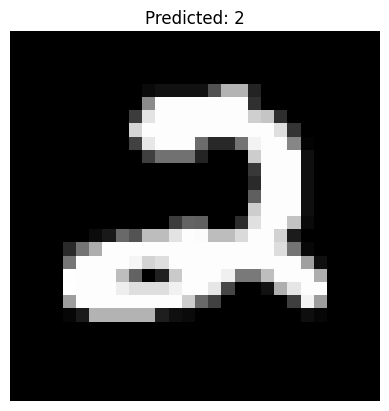

In [59]:
import numpy as np
import matplotlib.pyplot as plt

image_index = 0
predictions = cnn.predict(X_test_cnn)
predicted_label = np.argmax(predictions[image_index])
plt.imshow(X_test_img[image_index], cmap='gray')
plt.title(f"Predicted: {predicted_label}")
plt.axis('off')
plt.show()